Закон 1: y = 0.3285x² + (-3.4144)x + (2.7992),  невязка = 0.0594
Закон 2: y = -1.7284x + (2.5198)e^(-x) + (0.4568),  невязка = 0.0287

Лучший закон: 2 (невязка = 0.0287)


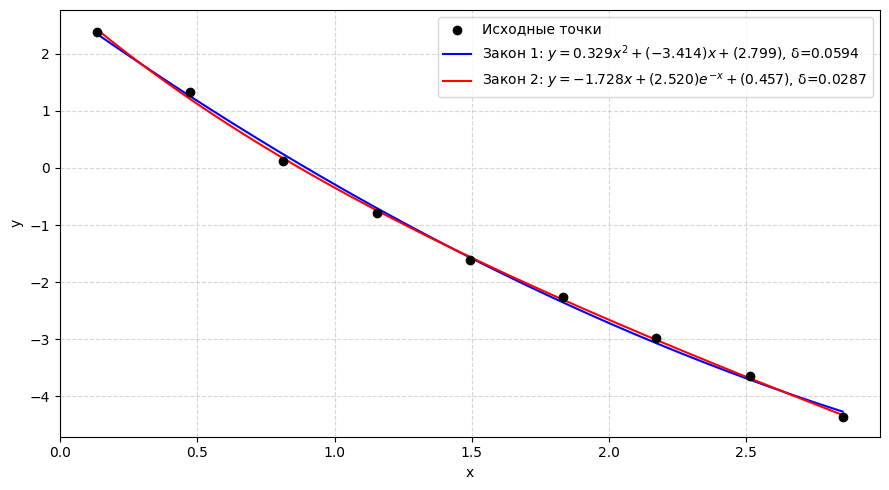

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

x = np.array([0.135, 0.475, 0.814, 1.154, 1.493, 1.833, 2.172, 2.512, 2.851])
y = np.array([2.382, 1.321, 0.117, -0.789, -1.606, -2.256, -2.985, -3.649, -4.365])
n = len(x)

A1 = np.array([
    [np.sum(x**4), np.sum(x**3), np.sum(x**2)],
    [np.sum(x**3), np.sum(x**2), np.sum(x)],
    [np.sum(x**2), np.sum(x),    n          ],
])
b1 = np.array([np.sum(x**2 * y), np.sum(x * y), np.sum(y)])
a1, b1c, c1 = solve(A1, b1)
y1 = a1*x**2 + b1c*x + c1
d1 = np.sum((y - y1)**2)

print(f"Закон 1: y = {a1:.4f}x² + ({b1c:.4f})x + ({c1:.4f}),  невязка = {d1:.4f}")

p1, p2, p3 = x, np.exp(-x), np.ones(n)
A2 = np.array([
    [np.sum(p1*p1), np.sum(p1*p2), np.sum(p1)],
    [np.sum(p2*p1), np.sum(p2*p2), np.sum(p2)],
    [np.sum(p1),    np.sum(p2),    n          ],
])
b2 = np.array([np.sum(y*p1), np.sum(y*p2), np.sum(y)])
a2, b2c, c2 = solve(A2, b2)
y2 = a2*x + b2c*np.exp(-x) + c2
d2 = np.sum((y - y2)**2)

print(f"Закон 2: y = {a2:.4f}x + ({b2c:.4f})e^(-x) + ({c2:.4f}),  невязка = {d2:.4f}")
print(f"\nЛучший закон: {'1' if d1 < d2 else '2'} (невязка = {min(d1,d2):.4f})")

xp = np.linspace(x[0], x[-1], 300)
plt.figure(figsize=(9, 5))
plt.scatter(x, y, color='black', zorder=5, label='Исходные точки')
plt.plot(xp, a1*xp**2 + b1c*xp + c1, 'b-', label=f'Закон 1: $y={a1:.3f}x^2+({b1c:.3f})x+({c1:.3f})$, δ={d1:.4f}')
plt.plot(xp, a2*xp + b2c*np.exp(-xp) + c2, 'r-', label=f'Закон 2: $y={a2:.3f}x+({b2c:.3f})e^{{-x}}+({c2:.3f})$, δ={d2:.4f}')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()